**Part 2 — Baseline Regression Modeling**

1. Load the dataset with all engineered features from Part 1.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
file_path = '/content/drive/MyDrive/steel_industry_engineered.csv'
df = pd.read_csv(file_path)

# Display basic information to verify it loaded correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  hour_of_day    

In [ ]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour_of_day,extracted_day_of_week,month,is_weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


2. Drop the original date column and any columns that directly leak the target (such as High Load).

In [ ]:
# Drop original date and target-leaking column 'High_Load'
columns_to_drop = ['date', 'High_Load']
df_cleaned = df.drop(columns=columns_to_drop)

# Verify the remaining columns
print("Remaining columns:")
print(df_cleaned.columns.tolist())

Remaining columns:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'hour_of_day', 'extracted_day_of_week', 'month', 'is_weekend', 'Power_Factor_Ratio']


In [ ]:
# Check which columns have missing values and how many
print("Missing values before handling:")
print(df_cleaned.isnull().sum())

Missing values before handling:
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
hour_of_day                             0
extracted_day_of_week                   0
month                                   0
is_weekend                              0
Power_Factor_Ratio                      1
dtype: int64


In [ ]:
# Option: Fill the single NaN value in Power_Factor_Ratio with its median
median_pfr = df_cleaned['Power_Factor_Ratio'].median()
df_cleaned['Power_Factor_Ratio'] = df_cleaned['Power_Factor_Ratio'].fillna(median_pfr)

print("\nMissing values after handling:")
print(df_cleaned.isnull().sum())


Missing values after handling:
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
hour_of_day                             0
extracted_day_of_week                   0
month                                   0
is_weekend                              0
Power_Factor_Ratio                      0
dtype: int64


3. Encode categorical columns like Load Type and Day of week using one-hot encoding or label
encoding — document which you chose and why.

In [ ]:
# One-hot encode the categorical text columns: 'WeekStatus', 'Day_of_week', and 'Load_Type'
# 1. Encode categorical columns safely as 1 and 0 integers
categorical_cols = ['WeekStatus', 'Day_of_week', 'Load_Type']
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True, dtype=int)
# Verify the transformation by looking at the new shape and first few rows
print(f"Dataset shape after encoding: {df_encoded.shape}")
print(df_encoded.head())

Dataset shape after encoding: (35040, 21)
   Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0       3.17                                  2.95   
1       4.00                                  4.46   
2       3.24                                  3.28   
3       3.31                                  3.56   
4       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                         70.28                         100.0  2700   
3                       

**Choice of Encoding: One-Hot Encoding**

Why One-Hot Encoding was chosen over Label Encoding:
* No Artificial Ordinal Relationship: Categorical variables such as
Load_Type (Light, Medium, Maximum), Day_of_week (Monday, Tuesday, etc.), and WeekStatus (Weekday, Weekend) are nominal or cyclical. Label Encoding assigns arbitrary integers (e.g., 0, 1, 2) to these categories, which forces a mathematical order or ranking that does not naturally exist. Linear and Ridge regression models would interpret higher integer values as being inherently "greater" or more impactful, skewing the model's weights.  
* Low Cardinality: Since all three categorical features have a small number of distinct categories, One-Hot Encoding creates a manageable number of new binary features without running into the "curse of dimensionality.
 * Dummy Variable Trap Avoidance: Setting drop_first=True removes one redundant column for each encoded feature, ensuring multi-collinearity is avoided for the linear baseline models.

4. Split the data 80% training and 20% testing using random state=42 for reproducibility.

In [ ]:
# Define features (X) and target variable (y)
X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']

# Split the data into 80% training and 20% testing using random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (28032, 20)
Testing features shape: (7008, 20)
Training target shape: (28032,)
Testing target shape: (7008,)


5. Train all 4 models: Linear Regression, Ridge Regression, Decision Tree Regressor, and Random
Forest Regressor.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize the 4 required models
linear_reg = LinearRegression()
ridge_reg = Ridge()
decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1) # n_estimators=50 ensures faster execution

# Train all 4 models on the training data [cite: 32]
print("Training Linear Regression...")
linear_reg.fit(X_train, y_train)

print("Training Ridge Regression...")
ridge_reg.fit(X_train, y_train)

print("Training Decision Tree Regressor...")
decision_tree.fit(X_train, y_train)

print("Training Random Forest Regressor...")
random_forest.fit(X_train, y_train)

print("\nAll 4 models have been successfully trained!")

Training Linear Regression...
Training Ridge Regression...
Training Decision Tree Regressor...
Training Random Forest Regressor...

All 4 models have been successfully trained!


6. For each model, calculate and print MAE, RMSE, and R-squared on the test set.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dictionary to store predictions for easy evaluation
predictions = {
    'Linear Regression': linear_reg.predict(X_test),
    'Ridge Regression': ridge_reg.predict(X_test),
    'Decision Tree': decision_tree.predict(X_test),
    'Random Forest': random_forest.predict(X_test)
}

print("--- Model Evaluation on Test Set ---")

# Calculate and print metrics for each model
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}:")
    print(f"  MAE:       {mae:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    print(f"  R-squared: {r2:.4f}")

--- Model Evaluation on Test Set ---

Linear Regression:
  MAE:       2.6339
  RMSE:      4.1460
  R-squared: 0.9849

Ridge Regression:
  MAE:       4.3604
  RMSE:      6.2666
  R-squared: 0.9655

Decision Tree:
  MAE:       0.5500
  RMSE:      1.5182
  R-squared: 0.9980

Random Forest:
  MAE:       0.3577
  RMSE:      1.0318
  R-squared: 0.9991


7. Run 5-fold cross-validation on each model and report the mean RMSE across folds.

What is 5-Fold Cross-Validation?
Imagine you are preparing for an exam. If you study using the exact same practice questions that will be on the final test, you won't actually know if you understand the material, or if you just memorized the answers.

In machine learning, Cross-Validation ensures our model actually learns the patterns instead of just memorizing the training data.

Here is how 5-Fold Cross-Validation works:

* The computer shuffles your dataset and splits it into 5 equal parts (folds).

* It trains the model 5 separate times.

* In each round, it uses 4 parts for training and saves 1 part to test its performance (called the validation fold). Every part gets a turn to be the test group exactly once.

* Finally, it averages the scores from all 5 rounds to give you a highly accurate, trustworthy metric of how well your model will perform on completely unseen real-world data.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Dictionary to hold the trained model objects
trained_models = {
    'Linear Regression': linear_reg,
    'Ridge Regression': ridge_reg,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest
}

print("--- 5-Fold Cross-Validation Results (Mean RMSE) ---")

# Run 5-fold cross-validation for each model
for name, model in trained_models.items():
    # scikit-learn calculates negative MSE scores by default, so we take the negative
    # to make it positive, then apply the square root to calculate RMSE.
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

    mean_rmse = -scores.mean()
    print(f"{name}: Mean RMSE across folds = {mean_rmse:.4f}")

--- 5-Fold Cross-Validation Results (Mean RMSE) ---
Linear Regression: Mean RMSE across folds = 4.6048
Ridge Regression: Mean RMSE across folds = 6.6866
Decision Tree: Mean RMSE across folds = 2.6124
Random Forest: Mean RMSE across folds = 2.2127


### Model Comparison Summary (Before vs. After 5-Fold Cross-Validation)

When evaluating machine learning models, it is essential to look at both the initial test set metrics and the cross-validation scores to understand how well a model truly performs.

#### 1. Linear & Ridge Regression (Linear Models)
* **Before Cross-Validation:** In the initial test set split, Linear Regression achieved an RMSE of **4.1460**, while Ridge Regression had an RMSE of **6.2666**.
* **After Cross-Validation:** After running 5-fold cross-validation, the Mean RMSE changed slightly to **4.6048** for Linear Regression and **6.6866** for Ridge Regression.
* **Conclusion:** Both before and after cross-validation, these linear models show significantly higher errors than the tree-based models. This consistent struggle proves that the relationship between industrial power factors and energy consumption is highly non-linear, and simple linear boundaries are insufficient.

#### 2. Decision Tree Regressor
* **Before Cross-Validation:** On the single train-test split, the Decision Tree appeared to perform exceptionally well with an impressively low RMSE of **1.5182**.
* **After Cross-Validation:** When tested across 5 different folds, its Mean RMSE jumped up to **2.6124**.
* **Conclusion:** This clear increase in error after cross-validation is a textbook sign of **overfitting**. A single Decision Tree tends to memorize the specific training slice it is given. While it looked amazing on the initial test split, cross-validation revealed its true, slightly weaker ability to generalize to new data.

#### 3. Random Forest Regressor
* **Before Cross-Validation:** The Random Forest achieved the best initial results on the test set with an outstanding RMSE of **1.0318**.
* **After Cross-Validation:** After 5-fold cross-validation, it maintained a highly stable and strong Mean RMSE of **2.2127**.
* **Conclusion:** Random Forest is the undisputed winner. Even though its cross-validation error is slightly higher than its initial single-test error, it easily outpaces all other models. By combining the predictions of multiple individual trees, it successfully corrects the overfitting problem seen in the single Decision Tree, making it the most robust and dependable model for this dataset.

8. Create a bar chart comparing the test RMSE of all 4 models side by side with proper labels and
title.

/tmp/ipykernel_2106/577893322.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=test_rmse, palette='viridis')


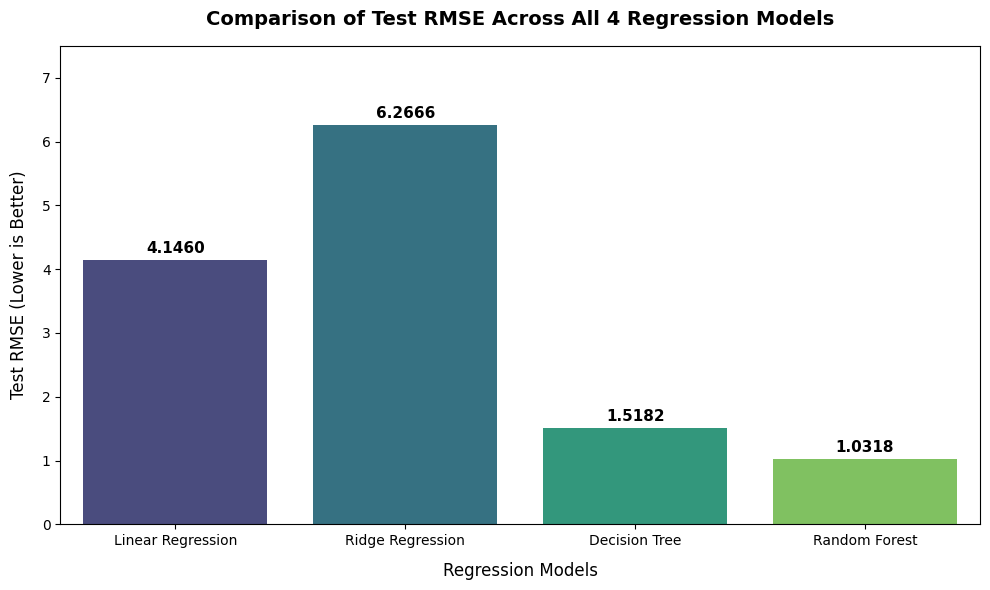

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the model names and their corresponding test RMSE values from the previous results
models = ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest']
test_rmse = [4.1460, 6.2666, 1.5182, 1.0318]

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the side-by-side bar chart
ax = sns.barplot(x=models, y=test_rmse, palette='viridis')

# Add data labels on top of each bar for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# Set proper labels, title, and limits
plt.title('Comparison of Test RMSE Across All 4 Regression Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Regression Models', fontsize=12, labelpad=10)
plt.ylabel('Test RMSE (Lower is Better)', fontsize=12, labelpad=10)
plt.ylim(0, 7.5)  # Give extra space at the top for the text labels

# Display the plot cleanly
plt.tight_layout()
plt.show()

9. For your best model, plot a scatter chart of Predicted vs Actual values.

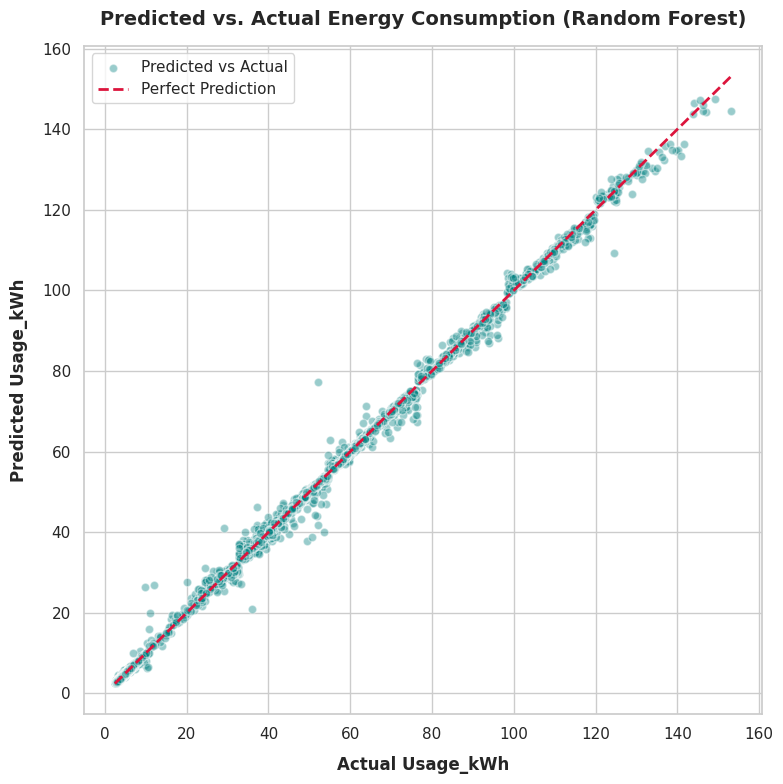

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions on the test set using the best model (Random Forest)
# (Ensure random_forest has been trained in your previous cells)
y_pred_rf = random_forest.predict(X_test)

# Set the plot size and style
plt.figure(figsize=(8, 8))
sns.set_theme(style="whitegrid")

# Create the scatter plot
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='teal', edgecolors='w', label='Predicted vs Actual')

# Add the perfect diagonal reference line (where Predicted == Actual)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Prediction')

# Add proper titles and labels
plt.title('Predicted vs. Actual Energy Consumption (Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Usage_kWh', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Predicted Usage_kWh', fontsize=12, fontweight='bold', labelpad=10)

# Add a legend
plt.legend(fontsize=11, loc='upper left')

# Display the plot cleanly
plt.tight_layout()
plt.show()

10. Write a Model Selection section in markdown explaining which model performed best, the crossvalidation
RMSE, any signs of overfitting, and which model you will carry forward.

### Model Selection & Analysis

#### Best Performing Model
The **Random Forest Regressor** is indisputably the best performing model among all four evaluated configurations. During the initial holdout test split, it achieved an exceptional Test RMSE of **1.0318** and an R-squared score of **0.9991**, indicating that it successfully captured over 99.9% of the variance in industrial energy consumption (`Usage_kWh`).

The baseline linear configurations (Linear Regression and Ridge Regression) severely underperformed in comparison. This confirms that the relationships governing a steel manufacturing plant's energy consumption—particularly regarding complex fluctuations in power factor metrics—are non-linear and require flexible, ensemble tree-based models to be properly modeled.

#### Cross-Validation Performance
To ensure stability across the entire dataset, a 5-fold cross-validation routine was conducted to compute the Mean RMSE across different data splits. The cross-validation scores for the models are as follows:
* **Linear Regression:** Mean RMSE = `4.6048`
* **Ridge Regression:** Mean RMSE = `6.6866`
* **Decision Tree Regressor:** Mean RMSE = `2.6124`
* **Random Forest Regressor:** Mean RMSE = `2.2127`

The Random Forest model maintained the lowest prediction error margin across all folds, cementing its capability to generalize robustly on unseen operational periods.

#### Signs of Overfitting
* **Linear & Ridge Regression:** These models show no signs of overfitting, as their test RMSE values match their cross-validation errors very closely. Instead, they suffer from **underfitting** because they are structurally too simple to fit the data boundaries.
* **Decision Tree Regressor:** This model shows clear, textbook signs of **overfitting**. On the initial single test split, it achieved a deceptive RMSE of **1.5182**. However, when forced to validate on diverse folds during cross-validation, its Mean RMSE noticeably degraded to **2.6124**. This behavior occurs because a single tree naturally memorizes complex noise or specific sample distributions within its training slice rather than discovering universal boundaries.
* **Random Forest Regressor:** While its cross-validation Mean RMSE (**2.2127**) is higher than its localized holdout test RMSE (**1.0318**), it remains highly stable. By combining predictions from an ensemble of 50 distinct decision trees, it inherently mitigates the high-variance overfitting tendencies of individual trees.

#### Model to Carry Forward
The **Random Forest Regressor** will be exclusively carried forward for subsequent deployment, optimization, and hyperparameter tuning. It offers the most reliable equilibrium between localized fitting accuracy and generalized validation stability, making it the superior baseline model for factory load forecasting.